<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/day_064_kernel_trick.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 64/365 — The Kernel Trick
## How can SVM solve nonlinear problems?

Yesterday we explored **Support Vector Machines (SVM)**.

A linear SVM finds a straight decision boundary.

But what if the data cannot be separated by a straight line?

That is where the **Kernel Trick** comes in.

A kernel lets SVM behave as if the data were mapped into a richer feature space, without explicitly creating all those transformed features.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


## 1. Create a nonlinear dataset


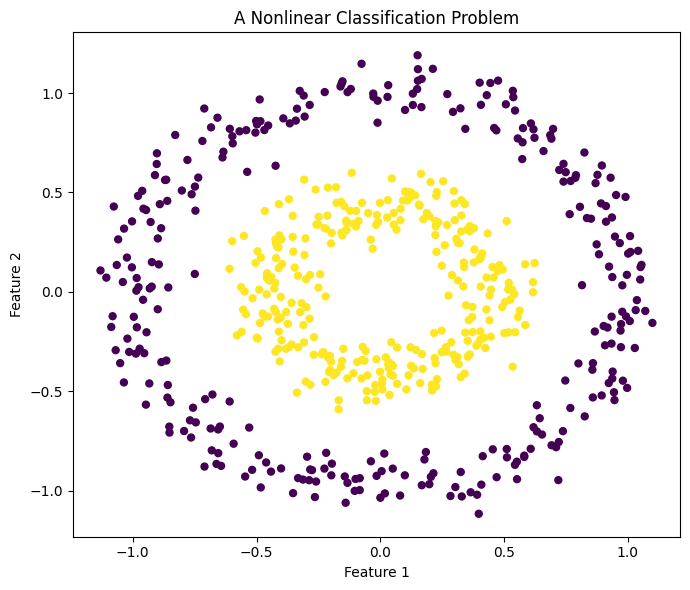

In [2]:
X,y=make_circles(
    n_samples=600,
    factor=0.45,
    noise=0.08,
    random_state=42
)

plt.figure(figsize=(7,6))
plt.scatter(X[:,0],X[:,1],c=y,s=25)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("A Nonlinear Classification Problem")
plt.tight_layout()
plt.show()


## 2. Compare Linear SVM vs RBF SVM


In [3]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.25,random_state=42,stratify=y
)

linear_model=Pipeline([
    ("scaler",StandardScaler()),
    ("svm",SVC(kernel="linear",C=1))
])

rbf_model=Pipeline([
    ("scaler",StandardScaler()),
    ("svm",SVC(kernel="rbf",C=1,gamma="scale"))
])

linear_model.fit(X_train,y_train)
rbf_model.fit(X_train,y_train)

linear_acc=accuracy_score(y_test,linear_model.predict(X_test))
rbf_acc=accuracy_score(y_test,rbf_model.predict(X_test))

comparison=pd.DataFrame({
    "Model":["Linear SVM","RBF SVM"],
    "Accuracy":[linear_acc,rbf_acc]
})

display(comparison.round(3))


,Model,Accuracy
0,Linear SVM,0.547
1,RBF SVM,1.000


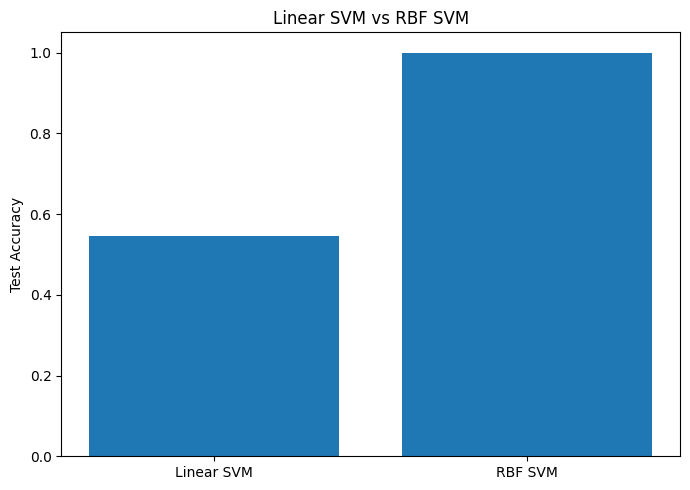

In [4]:
plt.figure(figsize=(7,5))
plt.bar(comparison["Model"],comparison["Accuracy"])
plt.ylabel("Test Accuracy")
plt.title("Linear SVM vs RBF SVM")
plt.tight_layout()
plt.show()


## 3. Visualize the nonlinear boundary

The RBF kernel can create a curved decision region that a linear SVM cannot.


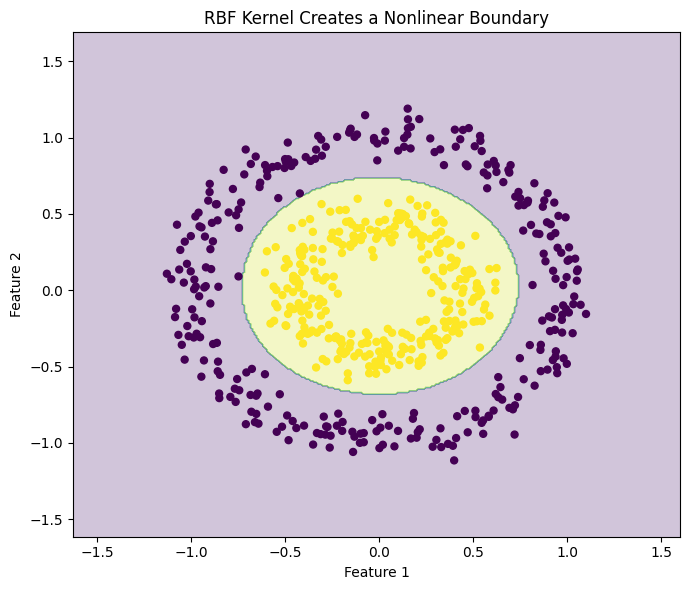

In [5]:
def plot_boundary(model,X,y,title):
    x_min,x_max=X[:,0].min()-0.5,X[:,0].max()+0.5
    y_min,y_max=X[:,1].min()-0.5,X[:,1].max()+0.5

    xx,yy=np.meshgrid(
        np.linspace(x_min,x_max,300),
        np.linspace(y_min,y_max,300)
    )

    grid=np.c_[xx.ravel(),yy.ravel()]
    z=model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(7,6))
    plt.contourf(xx,yy,z,alpha=0.25)
    plt.scatter(X[:,0],X[:,1],c=y,s=25)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_boundary(
    rbf_model,
    X,
    y,
    "RBF Kernel Creates a Nonlinear Boundary"
)


## 4. Kernel trick intuition

Suppose the original features are:

`x1, x2`

A nonlinear transformation might create:

`x1², x2², x1*x2`

This richer space may make the classes easier to separate.

Instead of explicitly creating every possible transformed feature, a kernel computes similarities as if the transformation had already happened.

That is the **kernel trick**.


## 5. Popular kernels

### Linear
Best when the separation is roughly linear.

### Polynomial
Captures polynomial relationships.

### RBF
One of the most popular kernels for nonlinear problems.

RBF similarity is based on:

`exp(-gamma * distance²)`

Nearby points have higher similarity.

Far-away points have lower similarity.


## 6. What does gamma do?

`gamma` controls how local the influence of each training point is.

Small gamma:
- broad influence
- smoother boundary
- can underfit

Large gamma:
- narrow influence
- more complex boundary
- can overfit


In [6]:
gamma_values=[0.01,0.1,1,10]
scores=[]

for gamma in gamma_values:
    model=Pipeline([
        ("scaler",StandardScaler()),
        ("svm",SVC(kernel="rbf",C=1,gamma=gamma))
    ])

    model.fit(X_train,y_train)
    scores.append(
        accuracy_score(
            y_test,
            model.predict(X_test)
        )
    )

gamma_results=pd.DataFrame({
    "Gamma":gamma_values,
    "Test Accuracy":scores
})

display(gamma_results.round(3))


,Gamma,Test Accuracy
0,0.01,0.72
1,0.10,1.00
2,1.00,1.00
3,10.00,1.00


## Enterprise intuition

Nonlinear relationships are common in:
- fraud detection
- churn prediction
- manufacturing fault detection
- risk classification

A kernel SVM can model complex decision boundaries without manually engineering every interaction.


## Important limitations

Kernel SVMs can become expensive on very large datasets.

They also require careful tuning of:
- C
- gamma
- kernel choice
- scaling

But the kernel trick remains one of the most important ideas in classical machine learning.


## What does this teach?

- Linear SVM creates linear boundaries.
- Real-world data may be nonlinear.
- Kernels let SVM model nonlinear patterns.
- The kernel trick avoids explicitly constructing every transformed feature.
- RBF is one of the most popular kernels.
- `gamma` controls how local each point's influence is.

> **The kernel trick lets SVM solve nonlinear problems by changing how similarity between points is measured.**


## References

- https://scikit-learn.org/stable/modules/svm.html
- https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
- https://scikit-learn.org/stable/auto_examples/svm/plot_rbf_parameters.html
- https://link.springer.com/article/10.1007/BF00994018
